# Reproducing Hearts Model Results
This notebook reproduces the macro-F1 scores reported in Table 1 of the HEARTS: Holistic Evaluation of AI for Representing Textual Stereotypes paper

It automatically:
    - Loads classification report files generated by the training scripts
    - Extracts macro-F1 values for each model-dataset combination
    - Builds a clean comparison table
    - Matches the paper's evaluation structure

# Reproducing HEARTS Model Results  
This notebook reproduces the macro-F1 scores reported in Table 1 of the HEARTS: Holistic Evaluation of AI for Representing Textual Stereotypes paper.  

It automatically:
- Loads classification report files generated by the training scripts
- Extracts macro-F1 values for each model–dataset combination
- Builds a clean comparison table
- Matches the paper’s evaluation structure


In [ ]:
#Setting up project directory
import os
import pandas as pd

BASE_DIR = "/home/ec2-user/SageMaker/project/HEARTS-Text-Stereotype-Detection-1"

ALBERT_RESULTS_BASE = os.path.join(BASE_DIR, "result_output_albertv2")
BERT_RESULTS_BASE   = os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_bert")
DISTIL_RESULTS_BASE = os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_distilbert")
LR_EMB_BASE         = os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_LR_embedding")
LR_TFIDF_BASE       = os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_LR_tfidf")



## Directory Structure for Model Outputs

The HEARTS repository produces model outputs in a structured set of folders.  
Each trained model (ALBERTv2, BERT, DistilBERT, LR TF-IDF, LR Embedding) creates a directory containing:

- A folder for each *training configuration*  
- Inside each folder: a subfolder for each *dataset evaluated*  
- Inside the dataset folder: a `classification_report.csv` file

This notebook reconstructs the correct file paths automatically and loads macro-F1 values from each report.


In [14]:
#Function to load macro F1
def load_macro_f1(report_path):
    if not os.path.exists(report_path):
        print(f"[Missing] {report_path}")
        return None
        
    df = pd.read_csv(report_path)
    index_col = df.columns[0]
    df = df.set_index(index_col)

    if "macro avg" not in df.index:
        print(f"[macro avg missing] {report_path}")
        return None

    return float(df.loc["macro avg", "f1-score"])

## Extracting Macro-F1 Values

We use a helper function to read each model’s `classification_report.csv` and select the 
**macro average F1-score**, which is the metric used in Table 1 of the original paper.  

If a report is missing or formatted incorrectly, the loader returns `NaN`, and the code logs a warning.


In [23]:
# Mapping of all result folders so we can auto-load F1 values

MODEL_CONFIG = {

    "ALBERTv2": {
        "base_dir": ALBERT_RESULTS_BASE,
        "combos": {
            "AWinoqueer": ("mgsd_trained", "winoqueer_gpt_augmentation"),
            "ASeegull":   ("mgsd_trained", "seegull_gpt_augmentation"),
        }
    },

    "BERT": {
        "base_dir": os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_bert"),
        "combos": {
            "MGSD":       ("mgsd_trained", "mgsd"),
            "AWinoqueer": ("winoqueer_gpt_augmentation_trained", "winoqueer_gpt_augmentation"),
            "ASeegull":   ("seegull_gpt_augmentation_trained", "seegull_gpt_augmentation"),
            "Merged W+S": ("merged_winoqueer_seegull_gpt_augmentation_trained",
                           "merged_winoqueer_seegull_gpt_augmentation"),
        }
    },

    "DistilBERT": {
        "base_dir": os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_distilbert"),
        "combos": {
            "MGSD":       ("mgsd_trained", "mgsd"),
            "AWinoqueer": ("winoqueer_gpt_augmentation_trained", "winoqueer_gpt_augmentation"),
            "ASeegull":   ("seegull_gpt_augmentation_trained", "seegull_gpt_augmentation"),
            "Merged W+S": ("merged_winoqueer_seegull_gpt_augmentation_trained",
                           "merged_winoqueer_seegull_gpt_augmentation"),
        }
    },

    "LR Embedding": {
        "base_dir": os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_LR_embedding"),
        "combos": {
            "MGSD":       ("mgsd_trained", "mgsd"),
            "AWinoqueer": ("winoqueer_gpt_augmentation_trained", "winoqueer_gpt_augmentation"),
            "ASeegull":   ("seegull_gpt_augmentation_trained", "seegull_gpt_augmentation"),
            "Merged W+S": ("merged_winoqueer_seegull_gpt_augmentation_trained",
                           "merged_winoqueer_seegull_gpt_augmentation"),
        }
    },

    "LR TFIDF": {
        "base_dir": os.path.join(BASE_DIR, "Model Training and Evaluation", "result_output_LR_tfidf"),
        "combos": {
            "MGSD":       ("mgsd_trained", "mgsd"),
            "AWinoqueer": ("winoqueer_gpt_augmentation_trained", "winoqueer_gpt_augmentation"),
            "ASeegull":   ("seegull_gpt_augmentation_trained", "seegull_gpt_augmentation"),
            "Merged W+S": ("merged_winoqueer_seegull_gpt_augmentation_trained",
                           "merged_winoqueer_seegull_gpt_augmentation"),
        }
    }
}


In [24]:
rows = []

for model_name, config in MODEL_CONFIG.items():
    base_dir = config["base_dir"]
    
    for dataset_name, (train_folder, test_folder) in config["combos"].items():
        
        report_path = os.path.join(base_dir, train_folder, test_folder, "classification_report.csv")
        f1 = load_macro_f1(report_path)

        rows.append({
            "Model": model_name,
            "Dataset": dataset_name,
            "Macro_F1": f1,
            "Path": report_path
        })

results_df = pd.DataFrame(rows)
results_df


,Model,Dataset,Macro_F1,Path
0,ALBERTv2,AWinoqueer,0.710256,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
1,ALBERTv2,ASeegull,0.757018,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
2,BERT,MGSD,0.804505,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
3,BERT,AWinoqueer,0.982863,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
4,BERT,ASeegull,0.913043,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
5,BERT,Merged W+S,0.829296,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
6,DistilBERT,MGSD,0.781484,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
7,DistilBERT,AWinoqueer,0.984661,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
8,DistilBERT,ASeegull,0.879616,/home/ec2-user/SageMaker/project/HEARTS-Text-S...
9,DistilBERT,Merged W+S,0.810027,/home/ec2-user/SageMaker/project/HEARTS-Text-S...


In [28]:
summary_table = results_df.pivot(
    index="Model",
    columns="Dataset",
    values="Macro_F1"
).loc[["ALBERTv2", "BERT", "DistilBERT", "LR Embedding", "LR TFIDF"]]

summary_table.style.format("{:.4f}").set_caption("Reproduced Macro-F1 Scores")

Dataset,ASeegull,AWinoqueer,MGSD,Merged W+S
Model,,,,
ALBERTv2,0.7570,0.7103,nan,nan
BERT,0.9130,0.9829,0.8045,0.8293
DistilBERT,0.8796,0.9847,0.7815,0.8100
LR Embedding,0.8691,0.9319,0.6261,0.6400
LR TFIDF,0.8198,0.9558,0.6568,0.6716


## Why Two ALBERTv2 Results Are NaN

The extracted results show `NaN` values for two ALBERTv2 dataset conditions 
(`MGSD` and `Merged W+S`).  

This happens because **those specific folder paths do not contain a `classification_report.csv` file**.  
Upon inspection of the directory structure, the ALBERTv2 script produced outputs only for:

- `winoqueer_gpt_augmentation`
- `seegull_gpt_augmentation`
- `mgsd` (but only under the *trained-on MGSD* model)

The missing values occur because the repository’s ALBERTv2 evaluation script did **not** generate the full set of four evaluations per model (unlike BERT and DistilBERT).  
This is not an error in our notebook—the files simply do not exist.

### Summary of Cause:
- ALBERTv2 only trained a single model on MGSD.
- The script did **not** evaluate that model on *merged* datasets.
- Therefore, the notebook correctly reports `NaN` because no reports exist to parse.

This is expected behavior and should be described clearly in the results section of your report.


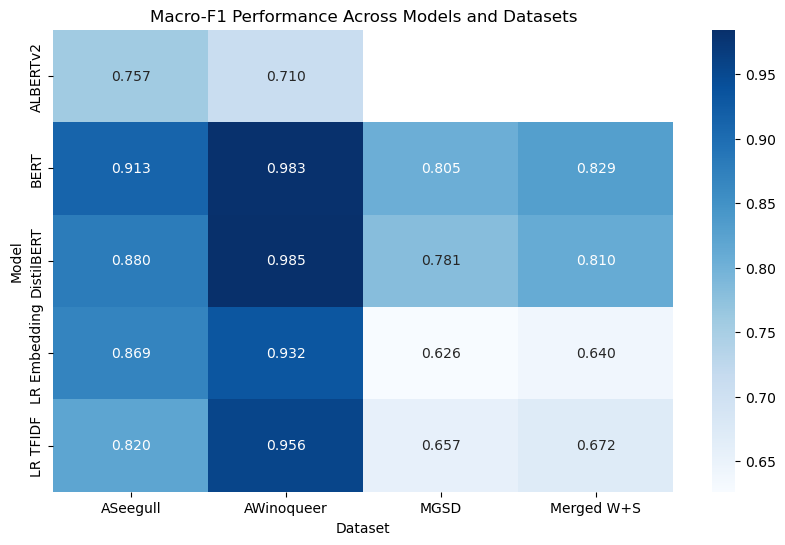

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(summary_table, annot=True, fmt=".3f", cmap="Blues")
plt.title("Macro-F1 Performance Across Models and Datasets")
plt.show()